# Processing of RO-Crate for publishing
This notebook will read and RO-Crate file from galaxy, extract the provenance information as PROV-O in JSON-LD and save it into a new version of the RO-Crate.

1. read galaxy ro-crate
2. read the workflow file to get the prospective provenance
3. read the workflow run to get the retrospective provenance
4. merge the provenances into a PROV-O graph
5. save the PROV-O graph in the RO-Crate
6. get a publishable package consisting of RO-Crate + context (a JSON-LD file). The context metadata as JSON-LD is intended to facilitate discovery and interoperability
7. publish package to Invenio RDM (Zenodo if possible)


In [34]:
import zipfile
from pathlib import Path
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
import json

import copy

# library to support visualisation of graphs
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph

# pyvis used to display the graphs
from pyvis.network import Network

# Namespaces
PROV = Namespace("http://www.w3.org/ns/prov#")
SCHEMA = Namespace("http://schema.org/")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
PPLAN = Namespace("https://vocab.linkeddata.es/p-plan#")
CDIFPROV = Namespace("https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#")

file_formats = {"txt":"text/plain", "cif": "chemical/x-cif",
                "png":"image/png", "prj": "application/vnd.demeter.athena",
                "sp":"text/csv", "gds":"text/csv", "feffit":"text/plain", 
                "feff":"text/csv", "zip":"application/zip",
                "inp":"chemical/x-feff-input",
                "tabular": "text/plain"
               }
data_products = ["png"]

# read file from zipped RO-Crate file
def get_file_from_rocratezip(zip_file, file_name):
    roc_zip_file = zipfile.ZipFile(zip_file)
    return roc_zip_file.open(file_name)
    
# Read the zipped crate and get main metadata file
def load_rocrate_metadata(crate_file):
    roc_zip_file = zipfile.ZipFile(crate_file)
    f = get_file_from_rocratezip(crate_file, "ro-crate-metadata.json")
    crate = json.load(f)
    return crate["@graph"]

#Return all JSON-LD entities of a given @type.
def find_entities(graph, type_name):
    return [e for e in graph if type_name in e.get("@type", [])]

#Convert RO-Crate IDs to URIs.
def to_uri(crate_base, entity_id):
    return URIRef(crate_base + entity_id)

#Convert json-ld crate to turtle
def crate_to_turtle(crate_path, save_path):
    g = Graph()
    roc_zip_file = zipfile.ZipFile(crate_path)
    f = roc_zip_file.open("ro-crate-metadata.json")
    g.parse(f,format="json-ld")
    out_ttl = Path(save_path, "ro-crate-metadata.ttl")
    print(f"saving to {out_ttl}")
    g.serialize(destination=out_ttl, format="turtle")

# get galaxy workflow file from RO-Crate
def get_workflow_json(ro_crate_zip):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_files = find_entities(graph, "File")
    workflow_file = ""
    for a in roc_files:
        if a['@id'][-3:] == ".ga" :
            workflow_file = a['@id']
            break    
    f = get_file_from_rocratezip(ro_crate_zip, workflow_file)
    wf_ga_json = json.load(f)
    return wf_ga_json

# get txt containing entities RO-Crate metadata:
# invocation, datasets, etc
def get_roc_json_part(ro_crate_zip, file_name):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_file = ""
    roc_all_files = find_entities(graph, "File")
    for a in roc_all_files:
        if file_name in a['@id']:
            roc_file = a['@id']
            break
    f = get_file_from_rocratezip(ro_crate_zip, roc_file) 
    file_json = json.load(f)
    return file_json

# data sets are mapped to history objects
def get_history_mapped_ds(datasets_json, history_mapping):
    ds_id = ""
    for ds in datasets_json:
        chain = ds.get("copied_from_history_dataset_association_id_chain", [])
        if history_mapping in chain or history_mapping == ds["encoded_id"]:
            ds_id = ds["encoded_id"]
    return ds_id

# link ds generator to corresponding wf step
def get_wf_step(ds_uri, a_graph):
    ds_label =  get_a_label(a_graph, ds_uri)
    ret_val = None
    # fetch steps have the ds_name as the label
    for an_activity, p, o in a_graph.triples((None, RDFS.label, Literal(ds_label))):
        ret_val = an_activity                
    return ret_val

# correct association of sw agents to actions instead of steps
def redirect_software_agents(a_graph):
    to_remove = set()
    to_add = set()
    
    for an_agent in a_graph.subjects(RDF.type, PROV.SoftwareAgent):
        for step in a_graph.subjects(PROV.wasAssociatedWith, an_agent):
            if (step, RDF.type, PPLAN.Step) not in a_graph:
                continue
    
            for prov_activity in a_graph.subjects(PPLAN.correspondsToStep, step):
                to_remove.add((step, PROV.wasAssociatedWith, an_agent))
                to_add.add((prov_activity, PROV.wasAssociatedWith, an_agent))
    
                for used in a_graph.objects(prov_activity, PROV.used):
                    to_add.add((used, PROV.wasAttributedTo, an_agent))
    
                for gen in a_graph.subjects(PROV.wasGeneratedBy, prov_activity):
                    to_add.add((gen, PROV.wasAttributedTo, an_agent))
        
    for triple in to_remove:
        a_graph.remove(triple)
    
    for triple in to_add:
        a_graph.add(triple)

# add custom labels to activities
def custom_labels(a_graph):
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                pref_label = ""
                if d_label == "larch_athena":
                    pref_label = "process and normalise XAS"
                elif d_label == "larch_artemis":
                    pref_label = "FEFF fit of XAS"
                elif d_label == "larch_select_paths":
                    pref_label = "select FEFF paths"
                elif d_label == "larch_feff":
                    pref_label = "calculate FEFF paths from crystal"
                elif d_label == "larch_lcf":
                    pref_label = "linear combination fit of XAS"
                elif d_label == "larch_plot":
                    pref_label = "plot XAS data"
                elif d_label == "larch_criteria_report":
                    pref_label = "report on FEFF fitting"
                elif d_label == "DATA_FETCH":
                    pref_label = "fetch data from history"
                elif d_label == "EXTRACT_DATASET":
                    pref_label = "extract dataset from collection"
                    
            if pref_label != "":
                a_graph.add((an_activity, SKOS.prefLabel, Literal(pref_label)))

def cdif_activities(a_graph):
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                cdif_type = CDIFPROV.Analysis
                if d_label == "larch_athena":
                    cdif_type = CDIFPROV.Analysis
                elif d_label == "larch_artemis":
                    cdif_type = CDIFPROV.Analysis
                elif d_label == "larch_select_paths":
                    cdif_type = CDIFPROV.Deriving
                elif d_label == "larch_feff":
                    cdif_type = CDIFPROV.Deriving
                elif d_label == "larch_lcf":
                    cdif_type = CDIFPROV.Analysis
                elif d_label == "larch_plot":
                    cdif_type = CDIFPROV.Deriving
                elif d_label == "larch_criteria_report":
                    cdif_type = CDIFPROV.Deriving
                elif d_label == "DATA_FETCH":
                    cdif_type = CDIFPROV.DataProvisioning
                elif d_label == "EXTRACT_DATASET":
                    cdif_type = CDIFPROV.Extracting
                    
            a_graph.add((an_activity, RDF.type, cdif_type))

def get_a_label(graph_thing, a_subject):
    # Try SKOS prefLabel
    for a_label in graph_thing.objects(a_subject, SKOS.prefLabel):
        return str(a_label)

    # Try RDFS label
    for a_label in graph_thing.objects(a_subject, RDFS.label):
        return str(a_label)
        
    return ""

# lookup the collections table to find the jobs associated to steps
def find_jobs_by_hda_id(invoked_jobs, data_collections, hda_list):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }
    # lookup map for collections by collection id
    collections_by_id = {c['encoded_id']: c for c in data_collections}
    
    for hda_id in hda_list:
        collection = collections_by_id.get(hda_id)
        if not collection:
            continue
    
        for element in collection['collection']['elements']:
            element_hda_id = element['hda']['encoded_id']
            job = jobs_by_output_hda.get(element_hda_id)
            if job:
                jobs_for_step.append(job['encoded_id'])
    return jobs_for_step

def find_jobs_by_ds_ids(invoked_jobs, ds_ids_list):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }    
    for ds_id in ds_ids_list:   
            job = jobs_by_output_hda.get(ds_id)
            if job:
                print(f"Found job {job['encoded_id']} for DS {ds_id}")
                jobs_for_step.append(job['encoded_id'])
    #print (f"jobs for step: {jobs_for_step}")
    return jobs_for_step

# job ids can be directly obtained from a job association, 
# implicit collection jobs or indirectly from
# dataset links or history dataset associations
# pending: generate activities and agents 
# for fetching scalar values (parameters)
def map_jobs_to_step(inv_step, invoked_jobs, ds_collections, ds_attributes, implicit_job_lookup):
    
    if inv_step.get("job"):
        return [inv_step["job"]["encoded_id"]]

    if inv_step.get("implicit_collection_jobs"):
        coll_id = inv_step["implicit_collection_jobs"].get("encoded_id")
        return implicit_job_lookup.get(coll_id, [])

    ds_links = [
        out["dataset_collection"]["encoded_id"]
        for out in inv_step.get("output_collections", [])
    ]
    
    job_ids = []
    if ds_links:
        job_ids += find_jobs_by_hda_id(invoked_jobs, ds_collections, ds_links)

    simple_outputs = [
        out["dataset"]["encoded_id"]
        for out in inv_step.get("outputs", [])
    ]
    ds_links += simple_outputs

    if simple_outputs:
        job_ids += find_jobs_by_ds_ids(invoked_jobs, simple_outputs)

        if not job_ids:
            copied_ids = [
                ds["copied_from_history_dataset_association_id_chain"][0]
                for ds in ds_attributes
                if ds["encoded_id"] in ds_links
            ]
            job_ids += find_jobs_by_ds_ids(invoked_jobs, copied_ids)
            
    return job_ids
    
# extract steps from wf and invocation files to create prov plan
def roc_provo(crate_path, out_path, output_file="galaxy_run_prov.ttl"):
    workflow_file = ""
    invocation_file = "" 

    # Load workflow (prospective provenance)
    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    # Load invocation (retrospective provenance)
    inv = get_roc_json_part(crate_path,"invocation_attrs.txt")
    inv_steps = inv[0].get("steps", {})

    # load implicit job collections ()
    # these are parallelised executions from a single step in the workflow
    implicit_job_links = get_roc_json_part(crate_path, "implicit_collection_jobs_attrs.txt")
    
    implicit_job_lookup = {
        jc["encoded_id"]: jc["jobs"]
        for jc in implicit_job_links
    }
    
    # Load dataset attributes (encoding, names, ) 
    # to gather dataset attributes
    ds_attributes = get_roc_json_part(crate_path,"datasets_attrs.txt")

    # load ds collections
    # these collections map to grouped inputs (using lists) which are unpacked by fetch data
    ds_collections = get_roc_json_part(file_path, "collections_attrs.txt")

    # Load job attributes
    # gather input links
    invoked_jobs = get_roc_json_part(crate_path,"jobs_attrs.txt")
    
    g = Graph()

    # define namespaces in graph
    for p, ns in [("prov", PROV), ("schema", SCHEMA), ("skos", SKOS), ("p-plan", PPLAN), ("cdifprov", CDIFPROV) ]:
        g.bind(p, ns)

    base = "/"

    # --- 1. Workflow definition as prov:Plan ---
    wf_uri = URIRef(base + "workflow")
    g.add((wf_uri, RDF.type, PPLAN.Plan))
    g.add((wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow"))))

    # --- 2. Prospective provenance: workflow steps ---
    for step_id, step in steps.items():
        step_uri = URIRef(base + f"step/{step_id}")
        g.add((step_uri, RDF.type, PPLAN.Step))
        step_label = step.get("label") or step.get("tool_id")
        g.add((step_uri, RDFS.label, Literal(step_label)))

        # Link step to workflow plan
        g.add(( step_uri, PPLAN.isStepOfPlan, wf_uri))

        # Prospective inputs
        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict) and "id" in inp:
                src = URIRef(base + f"step/{inp['id']}")
                g.add((step_uri, PPLAN.isPrecededBy, src))

    # --- 3. Retrospective provenance: actual execution --- 
    # invocations are only used to link actities to wf steps
    for inv_step in inv_steps:
        job_ids = map_jobs_to_step(inv_step, invoked_jobs, ds_collections, ds_attributes, implicit_job_lookup)

        step_uri = URIRef(base + f"step/{inv_step['order_index']}")

        if not job_ids:
            print(f"*** Not Linked: {step_uri} ***")
            print(inv_step)
            continue

        for job_id in job_ids:
            g.add((
                URIRef(base + f"run/{job_id}"),
                PPLAN.correspondsToStep,
                step_uri
            ))

    # Add datset attributes
    for a_ds in ds_attributes:
        ent_uri = (URIRef(base + f"dataset/{a_ds['encoded_id']}"))
        format_str =  file_formats[a_ds['extension']]
        
        g.add((ent_uri, RDF.type, PROV.Entity)) # duplicated only used for WF_inputs which are not in invocation
        g.add((ent_uri, RDF.type, CDIFPROV.Dataset)) #test adding cdif terminology
        g.add((ent_uri, DCTERMS.format, Literal(format_str)))
        g.add((ent_uri, DCTERMS.description, Literal(a_ds['info'])))
        g.add((ent_uri, SCHEMA.name, Literal(a_ds['file_name'])))
        g.add((ent_uri, SKOS.prefLabel, Literal(a_ds['name']) ))
        if a_ds['extension'] in data_products:
            g.add((ent_uri, RDF.type, CDIFPROV.DataProduct))
    
    # Add the missing links to inputs
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        # link all used datasets to activites
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((job_uri, PROV.used, ds_uri))
                
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
        tool_uri = URIRef(f"/srv/galaxy/var/shed_tools/{a_job['tool_id']}")# causing problems
        tool_version = a_job['tool_version']
        if "toolshed" in a_job['tool_id']:
            tool_label, tool_version  =   a_job['tool_id'].split("/")[-2:]
        elif a_job['command_line']:
             tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
        else:
            tool_uri = URIRef(base + f"galaxy_tool/{tool_label.lower()}")

        g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
        g.add((tool_uri, RDF.type, CDIFPROV.Machine)) #test adding cdif terminology
        
        g.add((tool_uri, RDFS.label, Literal(tool_label)))
        g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
        # This should only add labes for datafetch activites which are not invocations
        g.add((job_uri, RDF.type, PROV.Activity))
        g.add((job_uri, RDFS.label, Literal(tool_label)))
        g.add((job_uri, PROV.wasAssociatedWith, tool_uri))

        # link output_dataset_mappings
        for a_mapping in a_job['output_dataset_mapping']:
            for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
                a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasGeneratedBy, job_uri)) #already done for most only pending for data fetch
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
                # these are also for data fetch only
                # link to associated plan activity
                step_uri = get_wf_step(ds_uri, g)
                if step_uri != None:
                    g.add((job_uri, PPLAN.correspondsToStep, step_uri))
        
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
    # Assing human readable labels to activities
    custom_labels(g)

    # add cdif entity types
    cdif_activities(g)

    
    # --- Save ---
    save_ttl = Path(out_path, output_file)
    g.serialize(destination=save_ttl, format="turtle")
    
    graph_context={
            "prov": str(PROV),
            "p-plan": str(PPLAN),
            "schema": str(SCHEMA),
            "skos": str(SKOS),
            "rdfs": str(RDFS),
            "dcterms": str(DCTERMS),
            "cdifprov": str(CDIFPROV)
        }
    save_json = Path(out_path, output_file[:-4]+".jsonld")
    g.serialize(destination=save_json, format="json-ld", 
                context=graph_context, auto_compact=True, indent=2)
    return g 

In [35]:
input_folder = "./input"
# "FeS2-Analysis.rocrate.zip" # OK 
# "FeS2-Analysis-Mod_01.rocrate.zip" # OK  
# "Paper_1_Pt3Sn.rocrate.zip" # fail to link some activities to pplan step 1 (99) does not link parameters.
# "Paper_2_Diphosphine.rocrate.zip" # OK
# "Paper_3-Au-colloids202604.rocrate.zip" # OK Corrected ROC, fail was because of unasigned inputs
# "paper_4_Palladium-CO.rocrate.zip" # OK
# "Paper_5-LaMnO3-Catalytic-Behaviour.rocrate.zip" # OK 
# "Paper_6_100C_175C_300C.rocrate.zip" # OK
# "Paper_6-PdAl2O3_100C_175C_300C.rocrate.zip" # OK
# "Paper_7-MoOxAl2O3.rocrate.zip" # OK 
# "Paper_8-EXAFS-fitting.rocrate.zip" # fail to link activities to pplan step and activities to DS 2 (209)
# "Paper_9-N2O-LaMnO3-Figs1.rocrate.zip" # OK
# "Paper_9-N2O-LaMnO3-Figs6202604.rocrate.zip" # OK Corrected ROC and added SwAgent extract dataset
# "Invocation-of-CDIF-Test-2026-04-22.rocrate.zip" # First CDIF testing RO Crate

file_name = "FeS2-Analysis.rocrate.zip" # "FeS2-Analysis-Mod_01.rocrate.zip" #

output_folder = "./output"
working_folder = file_name[:-4]

file_path = Path(input_folder,file_name)

output_path = Path(output_folder, working_folder)

if output_path.exists():
    print(f"saving output to existing folder: {output_path}")
else :
    Path(output_path).mkdir(parents=True, exist_ok=True)
    print(f"created folder for saving output: {output_path}")


crate_to_turtle(file_path, output_path)

roc_graph = roc_provo(file_path, output_path, "galaxy_run_prov.ttl" )
#roc_graph2 = build_provo(file_path, output_path, "galaxy_run_prov.ttl" )

saving output to existing folder: output\FeS2-Analysis.rocrate
saving to output\FeS2-Analysis.rocrate\ro-crate-metadata.ttl
Found job c60463f2d425dc91 for DS 19a53e40e411a2fb
Found job 2029b88b74bf2376 for DS a3eccf3e1f18d050


In [3]:
from graphviz import Digraph
from IPython.display import display

import os

# this path is needed for grapviz to work on win
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

def draw_pplan_only(a_graph):
    dot = Digraph("prov")
    for s, p, o in a_graph:
        node_str = get_a_label(a_graph, s)
        if (s, RDF.type, PPLAN.Step) in a_graph:
            node_str = str(s) +"\n" + node_str # dont convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        if p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_only(a_graph):
    dot = Digraph("prov")
    for s, p, o in a_graph:
        # classify nodes
        node_str = get_a_label(a_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in a_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0> |<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in a_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_full(a_graph):
    dot = Digraph("prov")

    for s, p, o in a_graph:
         # classify nodes
        node_str = get_a_label(a_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in a_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # dont convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in a_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")
        elif (s, RDF.type, PPLAN.Step) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) +"\n"
            dot.node(s, label=node_str, shape="box")
            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
        elif p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

In [4]:
from collections import defaultdict

linked_activities = []
linked_steps = []
for an_activity, p, a_wf_step in roc_graph.triples((None, PPLAN.correspondsToStep, None)):
    #print (an_activity, p, a_wf_step)
    linked_activities.append(an_activity)
    linked_steps.append(a_wf_step)

not_linked = []
for an_activity, p, o in roc_graph.triples((None, RDF.type, PROV.Activity)):
    if not an_activity in linked_activities:
        not_linked.append(str(an_activity))

not_linked_steps = []
for a_step, p, o in roc_graph.triples((None, RDF.type, PPLAN.Step)):
    if not a_step in linked_steps:
        not_linked_steps.append(a_step)

print (f"{len(not_linked)} activities not linked")
print (f"{len(not_linked_steps)} steps not linked")

if not_linked:
    for an_activity, a_pred, an_object in roc_graph.triples((not_linked[0], None, None)):
        print(a_pred, an_object)

ds_collections = get_roc_json_part(file_path, "collections_attrs.txt")

# print(f"{ds_collections[0]} {ds_collections[0]['encoded_id']}")

ds_attributes = get_roc_json_part(file_path, "datasets_attrs.txt")
jobs_json = get_roc_json_part(file_path, "jobs_attrs.txt")
print(f"Jobs Count: {len(jobs_json)}")

for a_job in jobs_json:
    if f"/run/{a_job['encoded_id']}" in not_linked:
        print(f"not linked job: {a_job['encoded_id']} dataset mapping: {a_job['output_dataset_mapping']}")
        a_mapping_id = list(a_job['output_dataset_mapping'].values())[0][0]
        print(f"Looking for {a_mapping_id}")
        #a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
        for a_collection in ds_collections:
            print(f"** Collection: {a_collection['encoded_id']} has {len(a_collection['collection']['elements'])} elements**")
            for an_element in a_collection['collection']['elements']:
                if an_element['encoded_id'] == a_mapping_id:
                    print(an_element)
                    break
                elif an_element['hda']['encoded_id'] == a_mapping_id:
                    print(f"**** {a_job['encoded_id']} linked to hda element {a_mapping_id}")                
                    print(an_element)
        print(a_job)
        break

# test with 'encoded_id': '7a12fea16bebcd15'


hda_ids = ['7a12fea16bebcd15','e45da5c951a7d210','1187ba2a6772adee','c2a3aad94e445fae',
           '80d8e798d1a46c2b','9993f96157cf8cf6','950dfeb102d81a34',]

invocations_json = get_roc_json_part(file_path, "invocation_attrs.txt")
inv_steps = invocations_json[0]["steps"]
print(f"invocation steps: {len(invocations_json[0]['steps'])}")
for hda_id in hda_ids:
    for an_inv_step in invocations_json[0].get('steps'):
        for out_collect in an_inv_step["output_collections"]:
            if hda_id in out_collect['dataset_collection']['encoded_id']:
                print(f"Found {hda_id} in {an_inv_step['order_index']}") 
                #print(an_inv_step)
                for a_collection in ds_collections:
                    if a_collection['encoded_id'] == hda_id:
                        print(f"** Collection: {a_collection['encoded_id']} has {len(a_collection['collection']['elements'])} elements**")
                        #print(a_collection['collection']['elements'])
                        for an_element in a_collection['collection']['elements']:
                            for a_job in jobs_json:
                                a_mapping_id = list(a_job['output_dataset_mapping'].values())[0][0]
                                if(an_element['hda']['encoded_id'] == a_mapping_id):
                                    print(f"Found job {a_job['encoded_id']} for {an_element['hda']['encoded_id']} ")
                    
    #for a_ds_coll in ds_collections:
    #    for a_col_asoc in a_ds_coll['elements']:
    #        if a_col_asoc == 
    #invocations_json[0].get('steps')
#implicit_job_links = get_roc_json_part(file_path,"implicit_collection_jobs_attrs.txt")
#implicit_job_links

0 activities not linked
0 steps not linked
Jobs Count: 7
invocation steps: 7


In [5]:
def find_jobs_by_hda(invoked_jobs, invoked_steps, data_collections, hda_list):
    step_id = -1
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }
    # lookup map for collections by collection encoded id
    collections_by_id = {
          c['encoded_id']: c for c in data_collections
        }

    steps_by_collection_id = defaultdict(list)
    
    for step in invoked_steps:
        for out in step.get("output_collections", []):
            cid = out['dataset_collection']['encoded_id']
            steps_by_collection_id[cid].append(step)
    
    for hda_id in hda_list:
        steps = steps_by_collection_id.get(hda_id, [])
        for step in steps:
            print(f"Found {hda_id} in step {step['order_index']}")
            step_id = step['order_index']
            
        collection = collections_by_id.get(hda_id)
        if not collection:
            continue
    
        for element in collection['collection']['elements']:
            element_hda_id = element['hda']['encoded_id']
    
            job = jobs_by_output_hda.get(element_hda_id)
            if job:
                print(f"Found job {job['encoded_id']} for HDA {element_hda_id}")
                jobs_for_step.append(job['encoded_id'])
    #print (f"step id: {step_id}, jobs: {jobs_for_step}")
    return step_id, jobs_for_step

def find_jobs_by_hda_small(invoked_jobs, data_collections, hda_list):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }
    # lookup map for collections by collection id
    collections_by_id = {c['encoded_id']: c for c in data_collections}
    
    for hda_id in hda_list:
        print(hda_id)
        collection = collections_by_id.get(hda_id)
        print(collection)
        if not collection:
            print("not a collection, look in datasets")
            continue
    
        for element in collection['collection']['elements']:
            
            element_hda_id = element['hda']['encoded_id']
    
            job = jobs_by_output_hda.get(element_hda_id)
            if job:
                print(f"Found job {job['encoded_id']} for HDA {element_hda_id}")
                jobs_for_step.append(job['encoded_id'])
    print (f"step id: {step_id}, jobs: {jobs_for_step}")
    return jobs_for_step

def find_jobs_by_ds_ids(invoked_jobs, ds_ids_list, step_id):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }
    
    for ds_id in ds_ids_list:   
            job = jobs_by_output_hda.get(ds_id)
            if job:
                print(f"Found job {job['encoded_id']} for DS {ds_id}")
                jobs_for_step.append(job['encoded_id'])
    print (f"step id: {step_id}, jobs: {jobs_for_step}")
    return jobs_for_step

#def find_job_by_dsid(jobs_json, ds_details, ['d28c7de7a4bf240d']):


In [6]:
print(f"Collections: {len(ds_collections)}, not linked activities: {len(not_linked)}")
#not_linked[0]
step_id, jobs_found = find_jobs_by_hda(jobs_json, inv_steps, ds_collections, ['d28c7de7a4bf240d'])
print(step_id, jobs_found)

jobs_found = find_jobs_by_hda_small(jobs_json, ds_collections, ['d28c7de7a4bf240d'])
print(step_id, jobs_found)

jobs_found = find_jobs_by_ds_ids(jobs_json, ['d28c7de7a4bf240d'], 1)


Collections: 1, not linked activities: 0
-1 []
d28c7de7a4bf240d
None
not a collection, look in datasets
step id: -1, jobs: []
-1 []
step id: 1, jobs: []


In [7]:
jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in jobs_json
        }
jobs_by_output_hda.keys()

dict_keys(['09ac6ec4005c4034', '690106c6bb4c70fa', '53c727f5a4016499', 'cb5ba8fbb62127f3', '6fdc3f32e885fed5', '1f2f251d53270b2f', '254b3fc45bd8f606'])

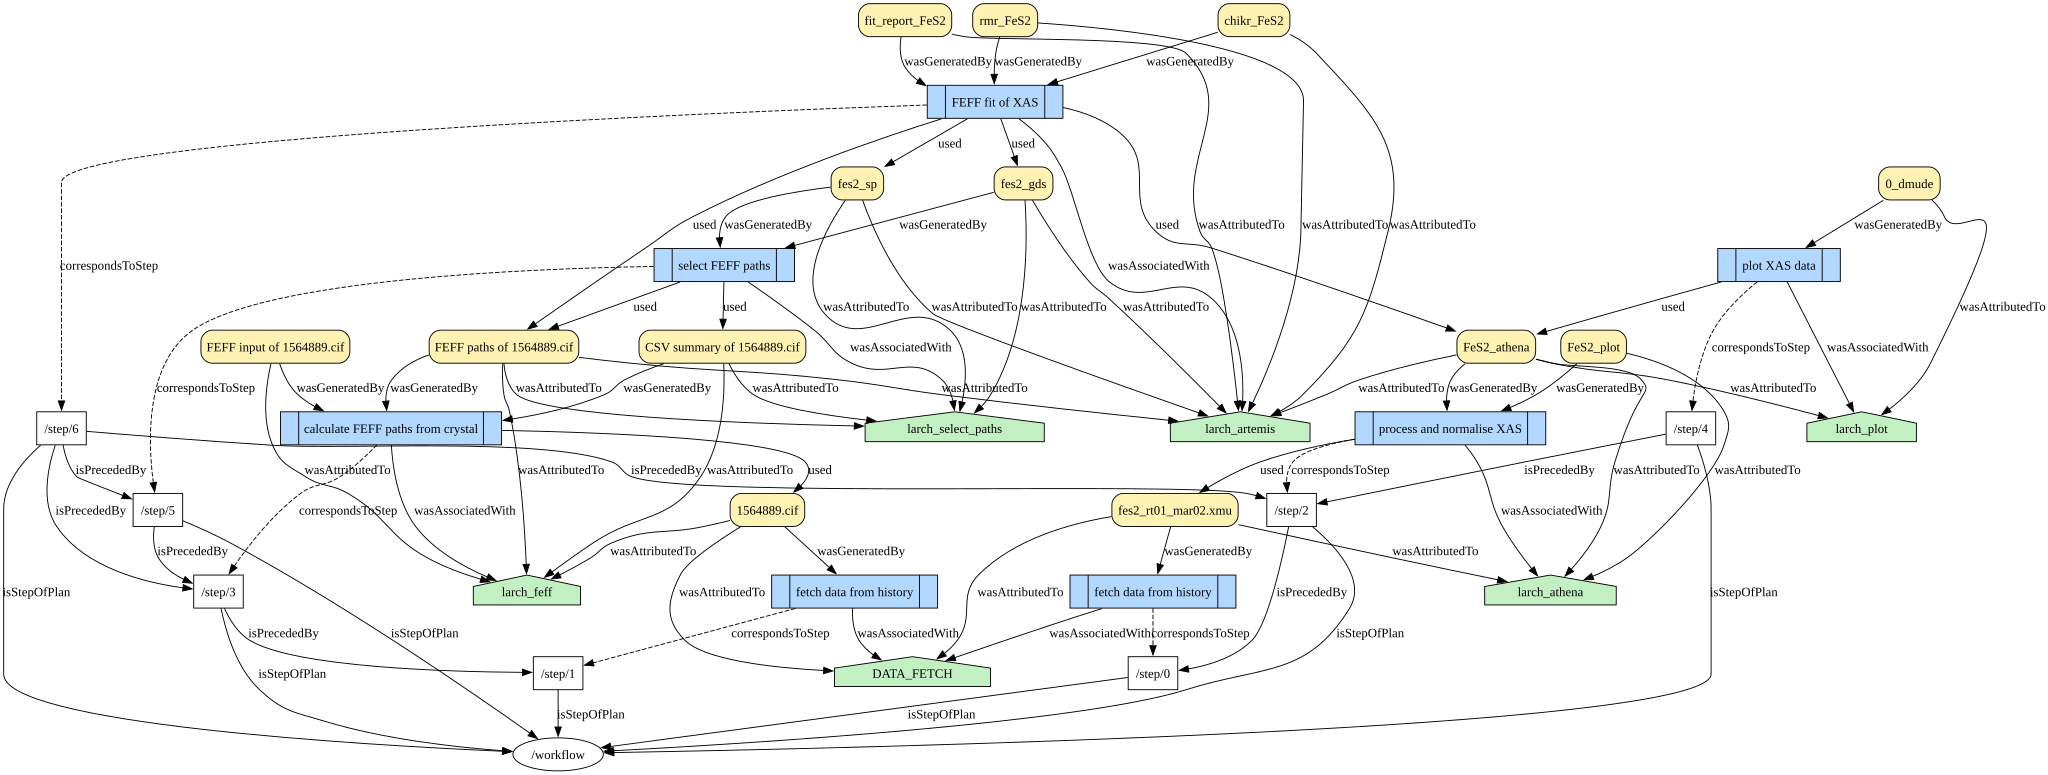

In [8]:
graph_file = Path(output_path, "prov_full") 
dot_prov_full = draw_prov_full(roc_graph)
dot_prov_full.render(graph_file, format="png")
display(dot_prov_full)

In [9]:
nx_graph = rdflib_to_networkx_graph(roc_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 102 nodes and 192 edges loaded successfully
nx.html


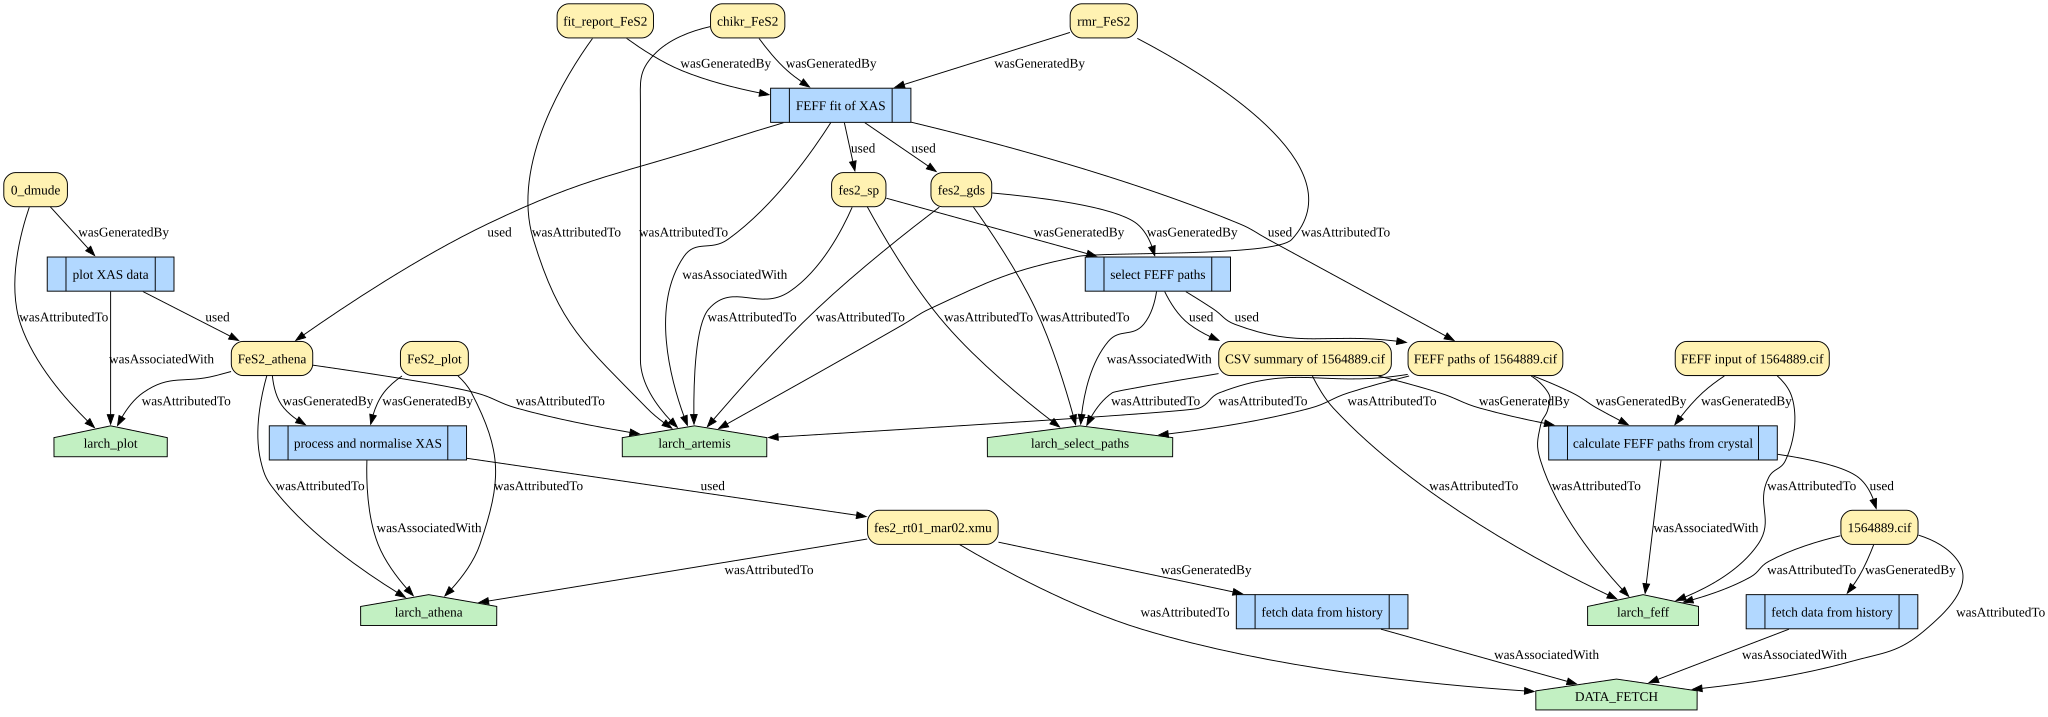

In [10]:
graph_file = Path(output_path, "prov_only") 
prov_dot = draw_prov_only(roc_graph)
prov_dot.render(graph_file, format="png")
display(prov_dot)

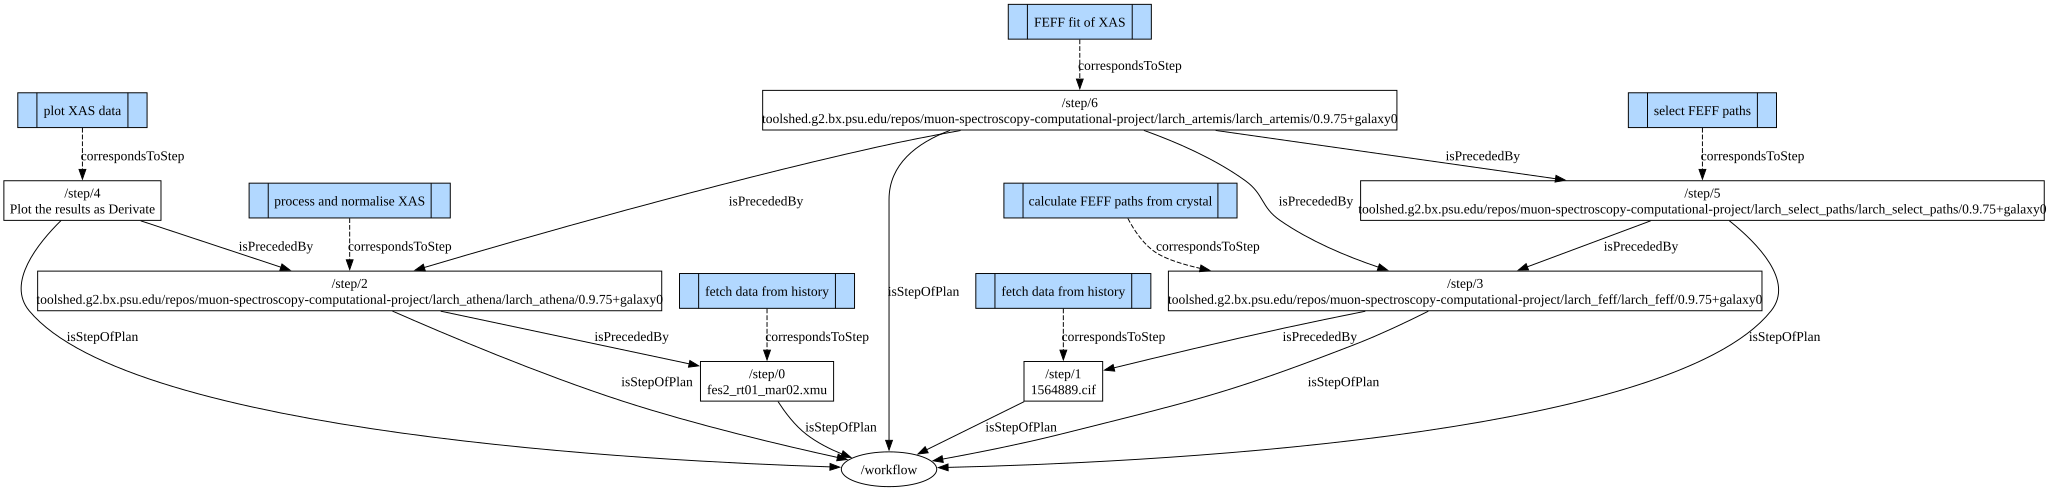

In [11]:
graph_file = Path(output_path, "pplan_only") 
plan_dot = draw_pplan_only(roc_graph)
plan_dot.render(graph_file, format="png")
display(plan_dot)

In [12]:
ds_attributes = get_roc_json_part(file_path, "datasets_attrs.txt")
print(f"Dataset count: {len(ds_attributes)}")
print(f"First Dataset: {ds_attributes[1]['name']}")
print(f"Dataset: {ds_attributes[1]}")
for a_ds in ds_attributes:
    print(f"{a_ds['encoded_id']}:\t {a_ds['name']}\t History {a_ds['history_encoded_id']}") 
    if 'sources' in a_ds['file_metadata'].keys():
        print(f"\t\t {a_ds['file_metadata']['sources'][0]['encoded_id']}") 
    if str(a_ds["encoded_id"]) in ["b0df60d9dafc8da2"]:
        for a_key in a_ds:
            print(f"{a_key}:  {a_ds[a_key]} ")

Dataset count: 13
First Dataset: 1564889.cif
Dataset: {'annotation': '', 'blurb': 'CIF file containing 0 structures', 'copied_from_history_dataset_association_id_chain': [], 'create_time': '2026-04-16 14:37:09.547408', 'dataset_uuid': '38ad5bf0-d528-4e4a-a925-7fbf8912589d', 'deleted': False, 'designation': None, 'encoded_id': '690106c6bb4c70fa', 'extension': 'cif', 'file_metadata': {}, 'file_name': 'datasets/1564889.cif_690106c6bb4c70fa.cif', 'hid': 1, 'history_encoded_id': 'c0638ea2d11151d4', 'info': "Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.\nYou can still use this dataset in tools and workflows.\nFor full metadata, ask your admin to install the 'ase' Python package\n            ", 'metadata': {'atom_data': [], 'chemical_formula': None, 'data_lines': 0, 'dbkey': '?', 'is_periodic': None, 'lattice_parameters': None, 'number_of_atoms': None, 'number_of_molecules': 0}, 'model_class': 'HistoryDatasetAssociation', 'name': '1564889.cif', 'peek': '#---

In [13]:
f_json = get_roc_json_part(file_path, "invocation_attrs.txt")
steps = f_json[0].get('steps')
print(f"Step Count {len(steps)}")
print("first step:")
steps[0]

Step Count 7
first step:


{'model_class': 'WorkflowInvocationStep',
 'state': 'scheduled',
 'create_time': '2026-04-16 14:39:10.847177',
 'update_time': '2026-04-16 14:39:10.847179',
 'order_index': 0,
 'action': None,
 'outputs': [{'output_name': 'output',
   'dataset': {'model_class': 'HistoryDatasetAssociation',
    'encoded_id': '09ac6ec4005c4034'}}],
 'output_collections': []}

In [14]:
#This works for jobs that have history 
def get_history_mapped_outputs(datasets_json, history_mapping):
    ds_id = ""
    for ds in datasets_json:
        chain = ds.get("copied_from_history_dataset_association_id_chain", [])
        if history_mapping in chain or history_mapping == ds["encoded_id"]:
            ds_id = ds["encoded_id"]
    return ds_id



jobs_json = get_roc_json_part(file_path, "jobs_attrs.txt")
print(f"Jobs Count: {len(jobs_json)}")
print("first job:")
print(jobs_json[0])
print(jobs_json[0]['output_dataset_mapping'])
the_mappings = jobs_json[0]['output_dataset_mapping']
base = "/"
for a_job in jobs_json:
    tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
    tool_version = a_job['tool_version']
    
    if "toolshed" in a_job['tool_id']:
        tool_label, tool_version  =   a_job['tool_id'].split("/")[-2:]
    tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
        
    print (f"Tool URI {tool_uri}")
    job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
    for a_mapping in a_job['input_dataset_mapping']:
        for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
            ds_uri = URIRef(base + f"dataset/{a_ds_id}")
            print(job_uri, PROV.used, ds_uri)
    for a_mapping in a_job['output_dataset_mapping']:
        for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
            print(f"This is the mapping ID: {a_mapping_id}")
            a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
            ds_uri = URIRef(base + f"dataset/{a_ds_id}")
            print(ds_uri)

Jobs Count: 7
first job:
{'command_line': "python '/srv/galaxy/server/data_fetch.py' --galaxy-root '/srv/galaxy/server' --datatypes-registry '/mnt/nfs/data/job_working_directory_swift/028/28542/registry.xml' --request-version '1' --request '/mnt/nfs/data/job_working_directory_swift/028/28542/configs/tmpbs7f06nw'", 'create_time': '2026-04-16T14:37:09.991082', 'encoded_id': '01fb96e1fa2767ef', 'exit_code': None, 'galaxy_version': '24.1', 'implicit_output_dataset_collection_mapping': {}, 'info': None, 'input_dataset_collection_element_mapping': {}, 'input_dataset_collection_mapping': {}, 'input_dataset_mapping': {}, 'job_messages': [], 'job_stderr': None, 'job_stdout': None, 'model_class': 'Job', 'output_dataset_collection_mapping': {}, 'output_dataset_mapping': {'output0': ['09ac6ec4005c4034']}, 'params': {'file_count': '1', 'files': [{'__index__': 0, 'file_data': '/mnt/nfs/data/tus/b37ed9896f2c4518d264d7cad73ccb13'}], 'paramfile': None, 'request_json': '{"targets": [{"destination": {"ty

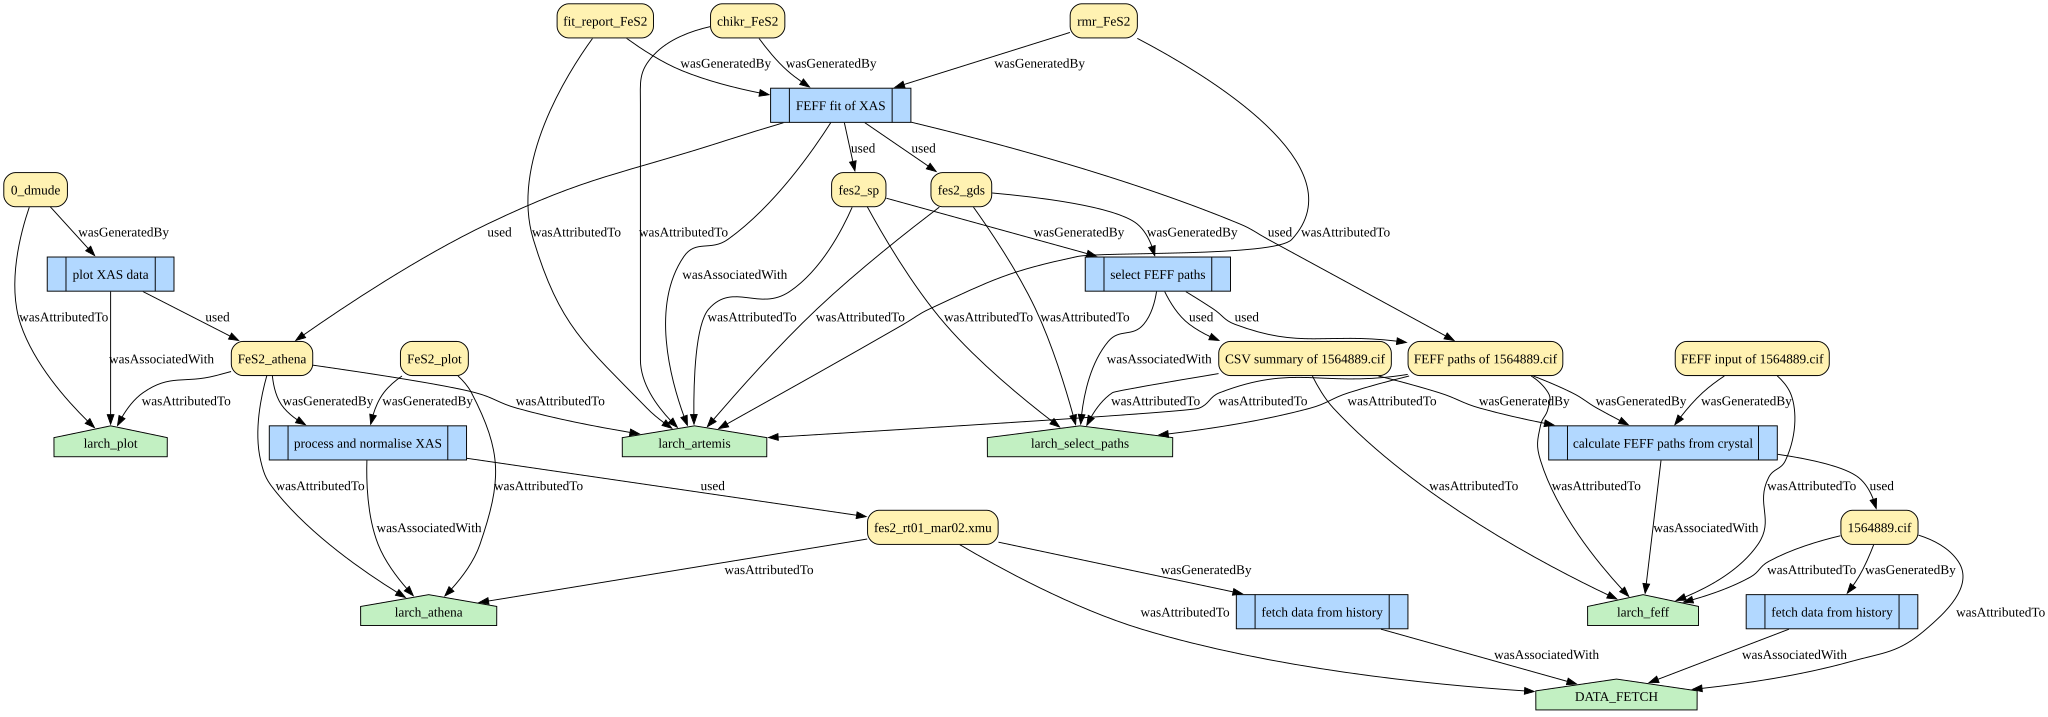

In [15]:
test_graph = copy.deepcopy(roc_graph)
#custom_labels(test_graph)

graph_file = Path(output_path, "prov_only")
prov_dot = draw_prov_only(test_graph)
prov_dot.render(graph_file, format="png")
display(prov_dot)

In [16]:
# put provenance in a table structure
import pandas as pd
# present data as html table
from IPython.display import display, HTML

qres = roc_graph.query("""
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX skos:   <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs:   <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <https://schema.org/>
PREFIX pplan:  <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activityLabel
  ?tools
  ?inputs
WHERE {
  ?output prov:wasGeneratedBy ?activity .

  OPTIONAL {
    SELECT ?output
           (COALESCE(MAX(?pref), MAX(?name), MAX(?label), STR(?output)) AS ?dataset)
    WHERE {
      OPTIONAL { ?output skos:prefLabel ?pref }
      OPTIONAL { ?output schema:name    ?name }
      OPTIONAL { ?output rdfs:label     ?label }
    }
    GROUP BY ?output
  }

  OPTIONAL {
    SELECT ?activity
           ?step
    WHERE {
      ?activity pplan:correspondsToStep ?step .
    }
  }

  OPTIONAL {
    SELECT ?activity
           (COALESCE(MAX(?pref), MAX(?name), MAX(?label), STR(?activity)) AS ?activityLabel)
    WHERE {
      OPTIONAL { ?activity skos:prefLabel ?pref }
      OPTIONAL { ?activity schema:name    ?name }
      OPTIONAL { ?activity rdfs:label     ?label }
    }
    GROUP BY ?activity
  }

  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(DISTINCT COALESCE(?pref, ?name, ?label, STR(?tool)); separator=", ") AS ?tools)
    WHERE {
      ?activity prov:wasAssociatedWith ?tool .
      OPTIONAL { ?tool skos:prefLabel ?pref }
      OPTIONAL { ?tool schema:name    ?name }
      OPTIONAL { ?tool rdfs:label     ?label }
    }
    GROUP BY ?activity
  }

  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(DISTINCT COALESCE(?pref, ?name, ?label, STR(?input)); separator=", ") AS ?inputs)
    WHERE {
      ?activity prov:used ?input .
      OPTIONAL { ?input skos:prefLabel ?pref }
      OPTIONAL { ?input schema:name    ?name }
      OPTIONAL { ?input rdfs:label     ?label }
    }
    GROUP BY ?activity
  }
}
ORDER BY ?step
""")

df = pd.DataFrame(
    [(str(s), str(a), str(t), str(o), str(i)) for s, o, a, t, i in qres],
    columns=["Step", "Activity", "Tool", "Dataset", "Inputs"]
)

In [17]:
display(HTML(df.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
1,/step/1,fetch data from history,DATA_FETCH,1564889.cif,None
2,/step/2,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
3,/step/2,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
4,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
5,/step/3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
6,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
7,/step/4,plot XAS data,larch_plot,0_dmude,FeS2_athena
8,/step/5,select FEFF paths,larch_select_paths,fes2_gds,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
9,/step/5,select FEFF paths,larch_select_paths,fes2_sp,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"


In [18]:


# get a dict of all dataset details
def dataset_details(a_graph):
    ds_details = {}
    for a_dataset in a_graph.subjects(RDF.type, PROV.Entity):
        relations = list(a_graph.predicate_objects(a_dataset))
        ds_data = [[p, o] for p, o in relations]
        ds_label = get_a_label(a_graph, a_dataset)
        ds_details[ds_label] = ds_data
    return ds_details

def get_ds_dataframe(ds_details, a_graph):
    processed_properties = []
    for p, o in ds_details:
        short_p = a_graph.namespace_manager.normalizeUri(p)
        short_o = a_graph.namespace_manager.normalizeUri(o) if isinstance(o, URIRef) else o
        #print (f"| {short_p:<20} | {str(short_o):<30} |")
        if "prov:wasAttributedTo" == str(short_p) or \
           "prov:wasGeneratedBy" == str(short_p):
            short_o = get_a_label(a_graph, o)
        #second_df.append({"property":short_p,"value":short_o}, ignore_index=True)
        processed_properties.append([short_p, short_o])
    ds_df = pd.DataFrame(
        [(p,o) for p, o in processed_properties],
        columns=["Property", "Value"]
    )
    return ds_df

dataset_details = dataset_details(roc_graph)
for a_ds in dataset_details:
    second_df = pd.DataFrame()

    processed_properties = []
    props_df = get_ds_dataframe(dataset_details[a_ds], roc_graph)
    display(HTML(f"<h3>{a_ds} Properties</h3>") )
    display(HTML(props_df.to_html().replace("\\n","<br>")))


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded txt file
3,schema1:name,datasets/fes2_rt01_mar02.xmu_09ac6ec4005c4034.txt
4,skos:prefLabel,fes2_rt01_mar02.xmu
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,chemical/x-cif
2,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package"
3,schema1:name,datasets/1564889.cif_690106c6bb4c70fa.cif
4,skos:prefLabel,1564889.cif
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_feff


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,application/vnd.demeter.athena
2,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8
3,schema1:name,datasets/FeS2_athena_53c727f5a4016499.prj
4,skos:prefLabel,FeS2_athena
5,prov:wasGeneratedBy,process and normalise XAS
6,prov:wasAttributedTo,larch_athena
7,prov:wasAttributedTo,larch_artemis
8,prov:wasAttributedTo,larch_plot


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,image/png
2,dcterms:description,"Attempting to read from /mnt/nfs/data/object_store_cache/7/c/c/dataset_7ccb21b8-05bc-493f-ab14-17acb125bd02.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_"
3,schema1:name,datasets/FeS2_plot_904ad182c115e0e4.png
4,skos:prefLabel,FeS2_plot
5,prov:wasGeneratedBy,process and normalise XAS
6,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/csv
2,dcterms:description,
3,schema1:name,datasets/fes2_gds_cb5ba8fbb62127f3.gds
4,skos:prefLabel,fes2_gds
5,prov:wasGeneratedBy,select FEFF paths
6,prov:wasAttributedTo,larch_select_paths
7,prov:wasAttributedTo,larch_artemis


...

,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,Archive: /mnt/nfs/data/object_store_cache/6/1/e/dataset_61e33a96-db0b-4e59-919e-d2e193af8cac.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/p
3,schema1:name,datasets/fit_report_FeS2_770bf34415d4254a.feffit
4,skos:prefLabel,fit_report_FeS2
5,prov:wasGeneratedBy,FEFF fit of XAS
6,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,image/png
2,dcterms:description,None
3,schema1:name,datasets/0_dmude_1f2f251d53270b2f.png
4,skos:prefLabel,0_dmude
5,prov:wasGeneratedBy,plot XAS data
6,prov:wasAttributedTo,larch_plot


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/csv
2,dcterms:description,Parsing dataset_38ad5bf0-d528-4e4a-a925-7fbf8912589d.dat and saving to feff/feff.inp*** feff input generated by xraylarch cif2feff using pymatgen ***TITLE Formula: FeS2TITLE SpaceGroup: PnnmTITLE # sites: 6* crystallographics sites: note that
3,schema1:name,datasets/CSV_summary_of_1564889.cif_b6c84ce9c0f2b764.feff
4,skos:prefLabel,CSV summary of 1564889.cif
5,prov:wasAttributedTo,larch_select_paths
6,prov:wasAttributedTo,larch_feff
7,prov:wasGeneratedBy,calculate FEFF paths from crystal


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,application/zip
2,dcterms:description,Parsing dataset_38ad5bf0-d528-4e4a-a925-7fbf8912589d.dat and saving to feff/feff.inp*** feff input generated by xraylarch cif2feff using pymatgen ***TITLE Formula: FeS2TITLE SpaceGroup: PnnmTITLE # sites: 6* crystallographics sites: note that
3,schema1:name,datasets/FEFF_paths_of_1564889.cif_47f2d609ff394b39.zip
4,skos:prefLabel,FEFF paths of 1564889.cif
5,prov:wasAttributedTo,larch_select_paths
6,prov:wasAttributedTo,larch_artemis
7,prov:wasAttributedTo,larch_feff
8,prov:wasGeneratedBy,calculate FEFF paths from crystal


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,chemical/x-feff-input
2,dcterms:description,Formula: FeS2SpaceGroup: Pnnm# sites: 6
3,schema1:name,datasets/FEFF_input_of_1564889.cif_254b3fc45bd8f606.inp
4,skos:prefLabel,FEFF input of 1564889.cif
5,prov:wasGeneratedBy,calculate FEFF paths from crystal
6,prov:wasAttributedTo,larch_feff


In [19]:
ds_attributes = get_roc_json_part(file_path, "datasets_attrs.txt")
jobs_json = get_roc_json_part(file_path, "jobs_attrs.txt")
print(f"Jobs Count: {len(jobs_json)}")

print("first job:")
print(jobs_json[0])

print(jobs_json[0]['output_dataset_mapping'])
the_mappings = jobs_json[0]['output_dataset_mapping']
base = "/"
for a_job in jobs_json:
    job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
    for a_mapping in a_job['output_dataset_mapping']:
        for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
            a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
            ds_uri = URIRef(base + f"dataset/{a_ds_id}")
            step_uri = get_wf_step(ds_uri, roc_graph)
            if step_uri != None:
               print((job_uri, PPLAN.correspondsToStep, step_uri))


Jobs Count: 7
first job:
{'command_line': "python '/srv/galaxy/server/data_fetch.py' --galaxy-root '/srv/galaxy/server' --datatypes-registry '/mnt/nfs/data/job_working_directory_swift/028/28542/registry.xml' --request-version '1' --request '/mnt/nfs/data/job_working_directory_swift/028/28542/configs/tmpbs7f06nw'", 'create_time': '2026-04-16T14:37:09.991082', 'encoded_id': '01fb96e1fa2767ef', 'exit_code': None, 'galaxy_version': '24.1', 'implicit_output_dataset_collection_mapping': {}, 'info': None, 'input_dataset_collection_element_mapping': {}, 'input_dataset_collection_mapping': {}, 'input_dataset_mapping': {}, 'job_messages': [], 'job_stderr': None, 'job_stdout': None, 'model_class': 'Job', 'output_dataset_collection_mapping': {}, 'output_dataset_mapping': {'output0': ['09ac6ec4005c4034']}, 'params': {'file_count': '1', 'files': [{'__index__': 0, 'file_data': '/mnt/nfs/data/tus/b37ed9896f2c4518d264d7cad73ccb13'}], 'paramfile': None, 'request_json': '{"targets": [{"destination": {"ty

In [20]:
wf = get_workflow_json(file_path)
steps = wf.get("steps", {})
print(f"Wrokflow steps: {len(steps)}")

for a_step in (steps):
    if steps[a_step]['content_id'] and "_DATA" in steps[a_step]['content_id']:
        print(f"{a_step}"*80)
        print(steps[a_step])

jobs_json = get_roc_json_part(file_path, "jobs_attrs.txt")
print(f"Jobs Count: {len(jobs_json)}")
for job_idx, a_job in enumerate(jobs_json):
    print(f"{job_idx}"*80)
    print(a_job)
    
invocations_json = get_roc_json_part(file_path, "invocation_attrs.txt")
inv_steps = invocations_json[0]["steps"]
print(f"invocation steps: {len(invocations_json[0]['steps'])}")
for a_step in inv_steps:
    print(a_step)

inv_steps[15]

Wrokflow steps: 7
Jobs Count: 7
00000000000000000000000000000000000000000000000000000000000000000000000000000000
{'command_line': "python '/srv/galaxy/server/data_fetch.py' --galaxy-root '/srv/galaxy/server' --datatypes-registry '/mnt/nfs/data/job_working_directory_swift/028/28542/registry.xml' --request-version '1' --request '/mnt/nfs/data/job_working_directory_swift/028/28542/configs/tmpbs7f06nw'", 'create_time': '2026-04-16T14:37:09.991082', 'encoded_id': '01fb96e1fa2767ef', 'exit_code': None, 'galaxy_version': '24.1', 'implicit_output_dataset_collection_mapping': {}, 'info': None, 'input_dataset_collection_element_mapping': {}, 'input_dataset_collection_mapping': {}, 'input_dataset_mapping': {}, 'job_messages': [], 'job_stderr': None, 'job_stdout': None, 'model_class': 'Job', 'output_dataset_collection_mapping': {}, 'output_dataset_mapping': {'output0': ['09ac6ec4005c4034']}, 'params': {'file_count': '1', 'files': [{'__index__': 0, 'file_data': '/mnt/nfs/data/tus/b37ed9896f2c4518d2

IndexError: list index out of range

In [ ]:
ds_attributes = get_roc_json_part(file_path, "datasets_attrs.txt")

jobs_json = get_roc_json_part(file_path, "jobs_attrs.txt")



print(f"Jobs Count: {len(jobs_json)}")
print("first job:")
print(jobs_json[0])
print(jobs_json[0]['output_dataset_mapping'])
the_mappings = jobs_json[0]['output_dataset_mapping']
base = "/"

for a_job in jobs_json:
    job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
    print(f"job URI: {job_uri}")
    for a_mapping in a_job['output_dataset_mapping']:
        print(f"History mappin:{a_mapping}") 
        for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
            print(f"Mapping ID:{a_mapping_id}") 
            a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
            ds_uri = URIRef(base + f"dataset/{a_ds_id}")
            step_uri = get_wf_step(ds_uri, roc_graph)
            if step_uri != None:
                print((job_uri, PPLAN.correspondsToStep, step_uri))
                print("*-"*40)


print (steps["0"])

In [ ]:
paths = list(Path(input_folder).glob('*.zip'))
len(paths)

In [ ]:
# get a dict of dataset details
def get_dataset_properties(a_dataset, a_graph):
    ds_data = []
    relations = list(a_graph.predicate_objects(a_dataset))
    ds_data =[["resource", a_dataset]] + [[p, o] for p, o in relations]
    return ds_data


for a_step in roc_graph.subjects(RDF.type, PPLAN.Step):
    for an_activity in roc_graph.subjects(PPLAN.correspondsToStep, a_step):
        for a_ds in roc_graph.subjects(PROV.wasGeneratedBy, an_activity):
            ds_properties = get_dataset_properties(a_ds,roc_graph)
            ds_label = get_a_label(roc_graph, a_ds)
            props_df = get_ds_dataframe(ds_properties, roc_graph)
            display(HTML(f"<h3>{ds_label} Properties</h3>") )
            display(HTML(props_df.to_html().replace("\\n","<br>")))
#wf = get_roc_json_part(file_path, "datasets_attrs.txt"))
#steps = wf.get("steps", {})




In [ ]:
roc_graph.subjects(PPLAN.isStepOfPlan, PPLAN.Plan)

In [ ]:
step_datasets_qry = """
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activity
WHERE {
  # core relation
  ?dataset prov:wasGeneratedBy ?activity .
  # wf step — related to activity
  OPTIONAL {
    SELECT ?activity
           ?step
    WHERE {
      ?activity pplan:correspondsToStep ?step .
    }
  }
}
ORDER BY ?step
"""
step_datasets_qry2 = """
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activity
WHERE {
  ?dataset prov:wasGeneratedBy ?activity .
  OPTIONAL {
    ?activity pplan:correspondsToStep ?step .
  }
}
ORDER BY ?step
"""
qres = roc_graph.query(step_datasets_qry2)

for step, a_ds, activity,  in qres:
    #print(str(step), str(dataset), str(activity))
    ds_properties = get_dataset_properties(a_ds,roc_graph)
    ds_label = get_a_label(roc_graph, a_ds)
    props_df = get_ds_dataframe(ds_properties, roc_graph)
    display(HTML(f"<h3>{ds_label} Properties</h3>") )
    display(HTML(props_df.to_html().replace("\\n","<br>")))




In [ ]:
step_datasets_qry = """
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activity
WHERE {
  # core relation
  ?dataset prov:wasGeneratedBy ?activity .
  # wf step — related to activity
  OPTIONAL {
    SELECT ?activity
           ?step
    WHERE {
      ?activity pplan:correspondsToStep ?step .
    }
  }
}
ORDER BY ?step
"""
step_datasets_qry2 = """
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activity
WHERE {
  ?dataset prov:wasGeneratedBy ?activity .
  OPTIONAL {
    ?activity pplan:correspondsToStep ?step .
  }
}
ORDER BY ?step
"""
qres = roc_graph.query(step_datasets_qry2)

for step, a_ds, activity,  in qres:
    #print(str(step), str(dataset), str(activity))
    ds_properties = get_dataset_properties(a_ds,roc_graph)
    ds_label = get_a_label(roc_graph, a_ds)
    props_df = get_ds_dataframe(ds_properties, roc_graph)
    display(HTML(f"<h3>{ds_label} Properties</h3>") )
    display(HTML(props_df.to_html().replace("\\n","<br>")))
    

In [ ]:
step_datasets_qry = """
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>
PREFIX prov:   <http://www.w3.org/ns/prov#>
# steps with no activities
SELECT ?step
WHERE {
  ?step rdf:type p-plan:Step .
  FILTER NOT EXISTS { [] p-plan:correspondsToStep ?step . }
}
"""

step_datasets_qry2 = """
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>
PREFIX prov:   <http://www.w3.org/ns/prov#>

# activities with no steps
SELECT ?an_activity
WHERE {
  ?an_activity rdf:type prov:Activity .
  FILTER NOT EXISTS { ?an_activity p-plan:correspondsToStep [] . }
}
"""

qres = roc_graph.query(step_datasets_qry)
print("***** steps with no activities")
for idx, a_step in enumerate(qres):
    for another_step in roc_graph.subjects(PPLAN.isPrecededBy, a_step[0]):
        print (f"{idx} {a_step[0]} preceded by {another_step}")
        

qres = roc_graph.query(step_datasets_qry2)
print("***** activities with no steps")
for an_activity in qres:
    print(an_activity[0])
    for a_ds in roc_graph.subjects(PROV.wasGeneratedBy, an_activity[0]):
        ds_label = get_a_label(roc_graph, a_ds)
        print(f"{an_activity[0]} generated ds: {a_ds} {ds_label}") 
        

list_results = [an_activity [0] for an_activity in qres]
print(list(qres))

In [27]:
only_subs="""
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>

SELECT DISTINCT ?s
WHERE {
  ?s ?p ?o .
}

"""

qres = roc_graph.query(only_subs)
list_results = [an_activity [0] for an_activity in qres]
print(f"\nSubjects: {len(list_results)}")
print(list_results)

only_agent="""
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT DISTINCT ?s
WHERE {
  ?s rdf:type prov:SoftwareAgent .
}

"""
qres = roc_graph.query(only_agent)
list_results = [an_agent[0] for an_agent in qres]
print(f"\nAgents: {len(list_results)}")
print(list_results)

only_activity="""
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT DISTINCT ?s
WHERE {
  ?s rdf:type prov:Activity .
}

"""
qres = roc_graph.query(only_activity)
list_results = [an_activity[0] for an_activity in qres]
print(f"\nActivities: {len(list_results)}")
print(list_results)

only_entity="""
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT DISTINCT ?s
WHERE {
  ?s rdf:type prov:Entity .
}

"""
qres = roc_graph.query(only_entity)
list_results = [an_entity[0] for an_entity in qres]
print(f"\nEntities: {len(list_results)}")
print(list_results)

only_step="""
PREFIX rdf:   <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX p-plan: <https://vocab.linkeddata.es/p-plan#>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT DISTINCT ?s
WHERE {
  ?s rdf:type p-plan:Step .
}

"""
qres = roc_graph.query(only_step)
list_results = [an_step[0] for an_step in qres]
print(f"\nSteps: {len(list_results)}")
print(list_results)



Subjects: 34
[rdflib.term.URIRef('/dataset/770bf34415d4254a'), rdflib.term.URIRef('/dataset/e6a34c9233fe2fb6'), rdflib.term.URIRef('/run/1b114888f3ab912d'), rdflib.term.URIRef('/dataset/47f2d609ff394b39'), rdflib.term.URIRef('/dataset/53c727f5a4016499'), rdflib.term.URIRef('/dataset/b6c84ce9c0f2b764'), rdflib.term.URIRef('/dataset/09ac6ec4005c4034'), rdflib.term.URIRef('/run/7e899e10c0ae0fe2'), rdflib.term.URIRef('/srv/galaxy/var/shed_tools/toolshed.g2.bx.psu.edu/repos/muon-spectroscopy-computational-project/larch_select_paths/larch_select_paths/0.9.75+galaxy0'), rdflib.term.URIRef('/dataset/254b3fc45bd8f606'), rdflib.term.URIRef('/srv/galaxy/var/shed_tools/toolshed.g2.bx.psu.edu/repos/muon-spectroscopy-computational-project/larch_feff/larch_feff/0.9.75+galaxy0'), rdflib.term.URIRef('/dataset/690106c6bb4c70fa'), rdflib.term.URIRef('/step/4'), rdflib.term.URIRef('/dataset/4bd1837d74a83cd9'), rdflib.term.URIRef('/srv/galaxy/server/data_fetch.py'), rdflib.term.URIRef('/dataset/1f2f251d53

In [ ]:
# read file from zipped RO-Crate file
def get_file_from_rocrate(zip_file, file_name):
    roc_zip_file = zipfile.ZipFile(zip_file)
    return roc_zip_file.open(file_name)


def load_part_as_jsonld(zip_file, file_name,):
    roc_zip_file = zipfile.ZipFile(zip_file)
    with roc_zip_file.open(file_name) as f:
        raw = json.load(f)

    # If it's already a JSON-LD object, return as-is
    if isinstance(raw, dict) and "@id" in raw:
        return raw

    # Wrap orphan attributes in a node
    return {
        "@id": file_name,
        "attributes": raw
    }

roc_parts = ['collections_attrs.txt', "datasets_attrs.txt","export_attrs.txt"]

# Read the zipped crate and get main metadata file
def load_rocrate_graph(crate_file):
    g = Graph()
    for p, ns in [("prov", PROV), ("schema", SCHEMA), ("skos", SKOS), ("p-plan", PPLAN)]:
        g.bind(p, ns)
    roc_zip_file = zipfile.ZipFile(crate_file)
    f = roc_zip_file.open("ro-crate-metadata.json")
    raw = json.load(f)
    for an_entry in raw['@graph']:
        if an_entry['@id'] == "export_attrs.txt":
            an_entry['@attributes'] = {"galaxy_export_version": "2"}
        
    
    g.parse(data = raw,format="json-ld", publicID="https://galaxy.org/roc/")
    for a_part in roc_parts:
        part_file = load_part_as_jsonld(crate_file, a_part)
        
        #print("*"*120)
        #print (part_file)
        g.parse(data=json.dumps(part_file), format="json-ld", publicID="https://w3id.org/ro/crate/1.1/context")
    return g

roc_graph = load_rocrate_graph(file_path)

In [ ]:
for idx, (s,p,o) in enumerate(roc_graph.triples((URIRef("https://galaxy.org/roc/export_attrs.txt"),None,None))):
    print (idx, s,p,o)
for idx, (s,p,o) in enumerate(roc_graph.triples((None,None,URIRef("https://galaxy.org/roc/export_attrs.txt")))):
    print (idx, s,p,o)

In [ ]:
for idx, (s,p,o) in enumerate(roc_graph.triples((None,None,None))):
    print (idx, s,p,o)

In [ ]:
from rdflib import Graph
import json

doc = {
    "@id": "part_txt",
    "value": 1
}

g = Graph()
g.parse(
    data=json.dumps(doc),
    format="json-ld",
    publicID="/"
)

print(list(g.subjects()))

In [ ]:
def build_provo(crate_path, out_path, output_file):
    u = lambda x: URIRef(f"/{x}")
    
    def add(*triple):
        g.add(triple)

    g = Graph()
    for p, ns in [("prov", PROV), ("schema", SCHEMA), ("skos", SKOS), ("p-plan", PPLAN)]:
        g.bind(p, ns)

    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    inv = get_roc_json_part(crate_path, "invocation_attrs.txt")[0]
    inv_steps = inv.get("steps", [])

    ds_attributes = get_roc_json_part(crate_path, "datasets_attrs.txt")
    invoked_jobs = get_roc_json_part(crate_path, "jobs_attrs.txt")

    # --- Workflow plan ---
    wf_uri = u("workflow")
    add(wf_uri, RDF.type, PPLAN.Plan)
    add(wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow")))

    # --- Prospective steps ---
    for sid, step in steps.items():
        step_uri = u(f"step/{sid}")
        add(step_uri, RDF.type, PPLAN.Step)
        add(step_uri, RDFS.label, Literal(step.get("label") or step.get("tool_id")))
        add(step_uri, PPLAN.isStepOfPlan, wf_uri)

        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict):
                add(step_uri, PPLAN.isPrecededBy, u(f"step/{inp['id']}"))

        if tool_id := step.get("tool_id"):
            tool_uri = u(tool_id)
            label, version = tool_id.split("/")[-2:]
            add(tool_uri, RDF.type, PROV.SoftwareAgent)
            add(tool_uri, RDFS.label, Literal(label))
            add(tool_uri, SKOS.prefLabel, Literal(label))
            add(tool_uri, SCHEMA.softwareVersion, Literal(version))
            add(step_uri, PROV.wasAssociatedWith, tool_uri)

    # --- Retrospective execution ---
    for inv_step in inv_steps:
        job = inv_step.get("job")
        if not job:
            continue

        job_id = job["encoded_id"]
        act_uri = u(f"run/{job_id}")
        step_uri = u(f"step/{inv_step['order_index']}")

        add(act_uri, RDF.type, PROV.Activity)
        add(act_uri, RDFS.label, Literal(f"Execution of step {inv_step['order_index']}"))
        add(act_uri, PPLAN.correspondsToStep, step_uri)

        for ds in inv_step.get("inputs", {}).values():
            ent = u(f"dataset/{ds['id']}")
            add(ent, RDF.type, PROV.Entity)
            add(act_uri, PROV.used, ent)

        for out in inv_step.get("outputs", []):
            ent = u(f"dataset/{out['dataset']['encoded_id']}")
            add(ent, RDF.type, PROV.Entity)
            add(ent, RDFS.label, Literal(out['output_name']))
            add(ent, PROV.wasGeneratedBy, act_uri)

    # --- Dataset attributes ---
    for ds in ds_attributes:
        ent = u(f"dataset/{ds['encoded_id']}")
        add(ent, RDF.type, PROV.Entity)
        add(ent, DCTERMS.format, Literal(file_formats[ds['extension']]))
        add(ent, DCTERMS.description, Literal(ds['info']))
        add(ent, SCHEMA.name, Literal(ds['file_name']))
        add(ent, SKOS.prefLabel, Literal(ds['name']))

    # --- Jobs input/output mappings ---
    for job in invoked_jobs:
        job_uri = u(f"run/{job['encoded_id']}")

        for ids in job.get("input_dataset_mapping", {}).values():
            for ds_id in ids:
                add(job_uri, PROV.used, u(f"dataset/{ds_id}"))

        if (job_uri, RDF.type, PROV.Activity) not in g:
            tool_uri = URIRef(job['command_line'].split()[1].strip("'"))
            label = job['tool_id'].strip("_")

            add(job_uri, RDF.type, PROV.Activity)
            add(job_uri, RDFS.label, Literal(label))
            add(tool_uri, RDF.type, PROV.SoftwareAgent)
            add(tool_uri, RDFS.label, Literal(label))
            add(tool_uri, SCHEMA.softwareVersion, Literal(job['tool_version']))
            add(job_uri, PROV.wasAssociatedWith, tool_uri)

            for ids in job.get("output_dataset_mapping", {}).values():
                for oid in ids:
                    ds_id = get_mapped_ds(ds_attributes, oid)
                    ds_uri = u(f"dataset/{ds_id}")
                    add(ds_uri, PROV.wasGeneratedBy, job_uri)
                    add(ds_uri, PROV.wasAttributedTo, tool_uri)

                    if step := get_wf_step(ds_uri, g):
                        add(job_uri, PPLAN.correspondsToStep, step)

    redirect_software_agents(g)

    #custom_labels(g)
    # --- Save ---
    g.serialize(Path(out_path, output_file), format="turtle")
    g.serialize(
        Path(out_path, output_file[:-4] + ".json"),
        format="json-ld",
        context={
            "@vocab": str(PROV),
            "prov": str(PROV),
            "p-plan": str(PPLAN),
            "schema": str(SCHEMA),
            "skos": str(SKOS),
            "rdfs": str(RDFS),
            "dcterms": str(DCTERMS),
        },
        auto_compact=True,
        indent=2,
    )
    return g

In [ ]:
for x,y,z in g.triples((None,None,None)):
    print (x,y,z)

In [ ]:
from rdflib import Graph
import json

doc = {
    "@context": {
        "value": "http://example.org/value"
    },
    "@id": "part_txt",
    "value": 1
}

g = Graph()
g.parse(
    data=json.dumps(doc),
    format="json-ld",
    publicID="http://test_roc.org/"
)

print(list(g.subjects()))

In [ ]:
#From this code:
from rdflib import Graph
import json

doc = {
    "@context": {
        "value": "http://example.org/value"
    },
    "@id": "part.txt",
    "value": 1
}

part_txt = [{"a_prop": "a_value"}, 
            {"another_prop": "another_value"}, ]


g = Graph()
g.parse(
    data=json.dumps(doc),
    format="json-ld",
    publicID="http://example.org/"
)

g.parse(
    
    data=json.dumps({"@context": {"@vocab": "http://example.org/"},
                     '@id': "http://example.org/part.txt", 
                     "attribs": part_txt}),
    format="json-ld",
    publicID="http://example.org/"
)


for x,y,z in g.triples((None,None,None)):
    print (x,y,z)

#I get this output:
#Nf198b7a223e04556897c42d06277a464 http://example.org/a_prop a_value
#http://example.org/part.txt http://example.org/attribs Nf198b7a223e04556897c42d06277a464
#http://example.org/part.txt http://example.org/attribs N59ff3083964248319b9ba696ab1eec0d
#N59ff3083964248319b9ba696ab1eec0d http://example.org/another_prop another_value
#http://example.org/part.txt http://example.org/value 1